# Fine-tuning of baseline model

### 01. Import libraries

In [4]:
from pathlib import Path
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

### 02. Paths and hyperparameters configuration

In [5]:
DATASET_DIR = Path('../dataset')
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'validation'
TEST_DIR = DATASET_DIR / 'test'

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 46

NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BASELINE_MODEL_PATH = '../models/best_convnext_tiny.pth'
FINETUNED_MODEL_PATH = '../models/best_convnext_tiny_finetuned.pth'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Using device: cpu


### 03. Creating datasets & dataloader

#### 03.01. Datasets

In [6]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])
val_transform = test_transform

In [8]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

#### 03.02. Dataloaders

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

### 04. Load baseline model

In [10]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

checkpoint = torch.load(BASELINE_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.to(DEVICE)
print('Baseline model loaded successfully.')

Baseline model loaded successfully.


### 05. ConvNeXt Tiny structure analysis

In [11]:
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
 

In [13]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 27,855,502
Trainable parameters: 27,855,502


### 06. Freezing all feature layers

In [14]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [15]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

Trainable parameters: 36,910


### 07. Classifier training

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [17]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0

#### 07.01. Training function

In [18]:
def train_classifier_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += (loss.item() * images.size(0))

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

#### 07.02. Validation function

In [19]:
def validate_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += (loss.item() * images.size(0))
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### 08. Learning rate scheduler

In [20]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [21]:
current_lr = optimizer.param_groups[0]['lr']
print(f'Current learning rate: {current_lr}')

Current learning rate: 1e-05


### 09. Fine-tuning function

In [23]:
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')

    train_loss, train_acc = train_classifier_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f'Train Loss: {train_loss:.4f}\n'
        f'Train Acc: {train_acc:.4f}\n'
        f'Val Loss: {val_loss:.4f}\n'
        f'Val Acc: {val_acc:.4f}\n'
        f'Learning Rate: {current_lr:.8f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), FINETUNED_MODEL_PATH)
        print('Best fine-tuned model updated!')

end_time = time.time()
print(f'Training time: {(end_time-start_time)/60:.2f} minutes')


Epoch 1/5


Validation: 100%|██████████| 222/222 [09:01<00:00,  2.44s/it]


Train Loss: 0.0776
Train Acc: 0.9779
Val Loss: 0.4867
Val Acc: 0.8622
Learning Rate: 0.00000655
Best fine-tuned model updated!

Epoch 2/5


Validation: 100%|██████████| 222/222 [09:06<00:00,  2.46s/it]


Train Loss: 0.0778
Train Acc: 0.9769
Val Loss: 0.4852
Val Acc: 0.8625
Learning Rate: 0.00000345
Best fine-tuned model updated!

Epoch 3/5


...

Train Loss: 0.0744
Train Acc: 0.9794
Val Loss: 0.4846
Val Acc: 0.8627
Learning Rate: 0.00000095
Best fine-tuned model updated!

Epoch 4/5


Validation: 100%|██████████| 222/222 [08:58<00:00,  2.43s/it]


Train Loss: 0.0750
Train Acc: 0.9795
Val Loss: 0.4844
Val Acc: 0.8625
Learning Rate: 0.00000000

Epoch 5/5


Validation: 100%|██████████| 222/222 [09:00<00:00,  2.44s/it]

Train Loss: 0.0745
Train Acc: 0.9791
Val Loss: 0.4844
Val Acc: 0.8625
Learning Rate: 0.00000095
Training time: 262.63 minutes


### 10. Visualize training results

#### 10.01. Loss

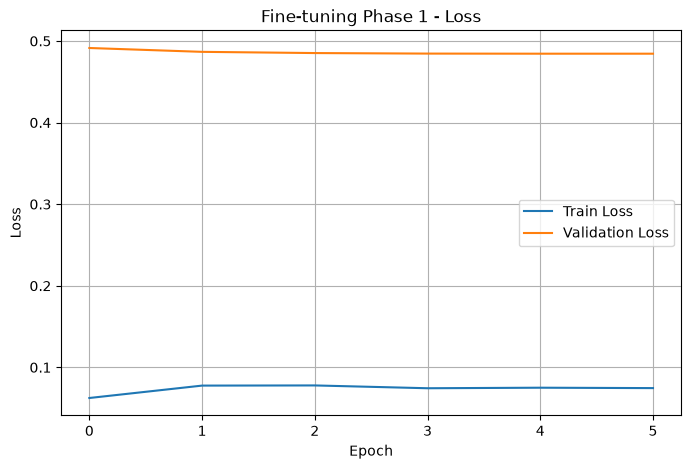

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning Phase 1 - Loss')
plt.legend()
plt.grid()
plt.show()

#### 10.02. Accuracy

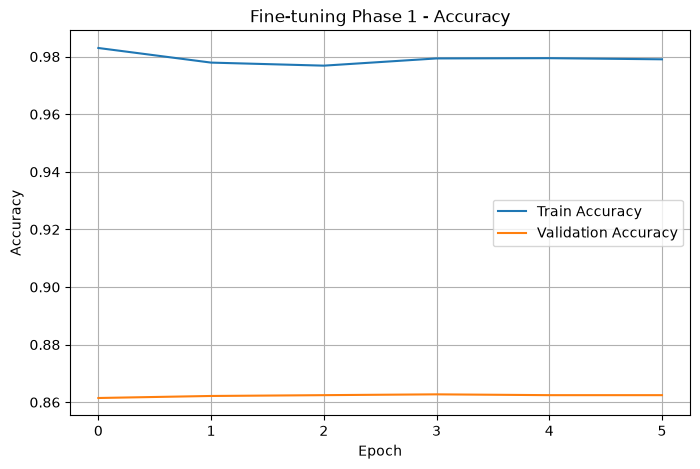

In [25]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-tuning Phase 1 - Accuracy')
plt.legend()
plt.grid()
plt.show()

### 11. Unfreeze last ConvNeXt stage

In [27]:
model.load_state_dict(
    torch.load(FINETUNED_MODEL_PATH, map_location=DEVICE)
)
model = model.to(DEVICE)

print('Phase 1 model loaded successfully.')

Phase 1 model loaded successfully.


#### 11.01. Check current parameters

In [28]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 27,855,502
Trainable parameters: 36,910


#### 11.02. Unfreezing

In [29]:
for param in model.features[7].parameters():
    param.requires_grad = True

In [30]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
percentage = (trainable_params / total_params) * 100

print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {percentage:.2f}%")

Trainable parameters: 14,326,318
Percentage trainable: 51.43%


### 12. II phase of fine-tuning

#### 12.01. Hyperparameters

In [31]:
FINE_TUNE_EPOCHS = 10
FINE_TUNE_LR = 1e-6
WEIGHT_DECAY = 1e-4

#### 12.02. Optimizer

In [32]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINE_TUNE_LR,
    weight_decay=WEIGHT_DECAY
)

#### 12.03. Scheduler

In [33]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINE_TUNE_EPOCHS)

#### 12.04. Metrics

In [34]:
phase2_train_losses = []
phase2_val_losses = []
phase2_train_accs = []
phase2_val_accs = []
best_phase2_acc = best_val_acc

### 13. Train loop - phase II

In [35]:
start_time = time.time()

for epoch in range(FINE_TUNE_EPOCHS):
    print(f"\nPhase 2 Fine-tuning Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")

    train_loss, train_acc = train_classifier_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()
    phase2_train_losses.append(train_loss)
    phase2_val_losses.append(val_loss)
    phase2_train_accs.append(train_acc)
    phase2_val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Train Loss: {train_loss:.4f}\n'
        f'Train Acc: {train_acc:.4f}\n'
        f'Val Loss: {val_loss:.4f}\n'
        f'Val Acc: {val_acc:.4f}\n'
        f'Learning Rate: {current_lr:.8f}'
    )

    if val_acc > best_phase2_acc:
        best_phase2_acc = val_acc
        torch.save(
            model.state_dict(),
            FINETUNED_MODEL_PATH
        )

        print('Best Phase 2 model updated!')

end_time = time.time()
print(f'Training time: {(end_time-start_time)/60:.2f} minutes')


Phase 2 Fine-tuning Epoch 1/10


Validation: 100%|██████████| 222/222 [09:01<00:00,  2.44s/it]


Train Loss: 0.0742
Train Acc: 0.9783
Val Loss: 0.4816
Val Acc: 0.8625
Learning Rate: 0.00000098

Phase 2 Fine-tuning Epoch 2/10


Validation: 100%|██████████| 222/222 [09:03<00:00,  2.45s/it]


Train Loss: 0.0699
Train Acc: 0.9797
Val Loss: 0.4797
Val Acc: 0.8632
Learning Rate: 0.00000090
Best Phase 2 model updated!

Phase 2 Fine-tuning Epoch 3/10


...

Train Loss: 0.0642
Train Acc: 0.9823
Val Loss: 0.4772
Val Acc: 0.8653
Learning Rate: 0.00000010

Phase 2 Fine-tuning Epoch 9/10


Validation: 100%|██████████| 222/222 [09:03<00:00,  2.45s/it]


Train Loss: 0.0657
Train Acc: 0.9820
Val Loss: 0.4772
Val Acc: 0.8653
Learning Rate: 0.00000002

Phase 2 Fine-tuning Epoch 10/10


Validation: 100%|██████████| 222/222 [08:59<00:00,  2.43s/it]

Train Loss: 0.0645
Train Acc: 0.9826
Val Loss: 0.4772
Val Acc: 0.8653
Learning Rate: 0.00000000
Training time: 614.13 minutes


### 14. Visualize training loop - phase 2

#### 14.01. Loss

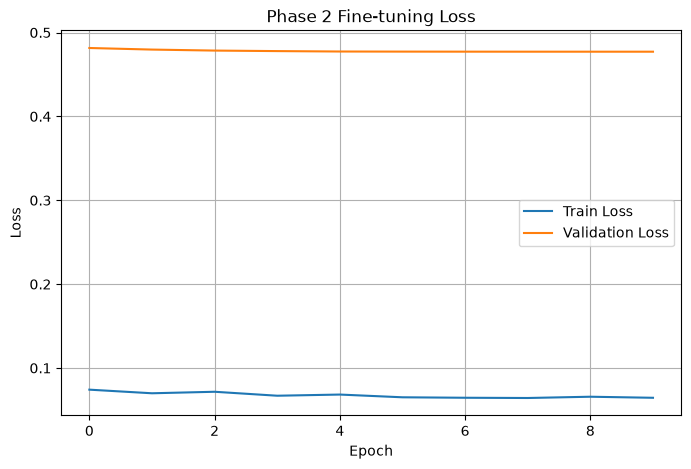

In [36]:
plt.figure(figsize=(8,5))

plt.plot(phase2_train_losses, label='Train Loss')
plt.plot(phase2_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Phase 2 Fine-tuning Loss')
plt.legend()
plt.grid()
plt.show()

#### 14.02. Accuracy

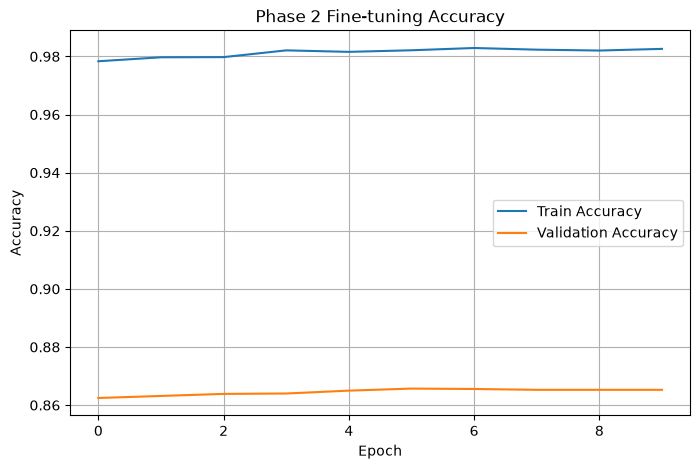

In [37]:
plt.figure(figsize=(8,5))

plt.plot(phase2_train_accs, label='Train Accuracy')
plt.plot(phase2_val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Phase 2 Fine-tuning Accuracy')
plt.legend()
plt.grid()
plt.show()

### 15. Compare baseline and fine-tuned models

In [38]:
baseline_accuracy = 0.8598
final_accuracy = best_phase2_acc

In [42]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['Baseline ConvNeXt Tiny', 'Fine-tuned ConvNeXt Tiny'],
    'Validation accuracy': [baseline_accuracy, final_accuracy],
    'Validation accuracy[%]': [round(baseline_accuracy*100, 2), round(final_accuracy*100, 2)]
})

comparison_df

,Model,Validation accuracy,Validation accuracy[%]
0,Baseline ConvNeXt Tiny,0.859800,85.98
1,Fine-tuned ConvNeXt Tiny,0.865691,86.57


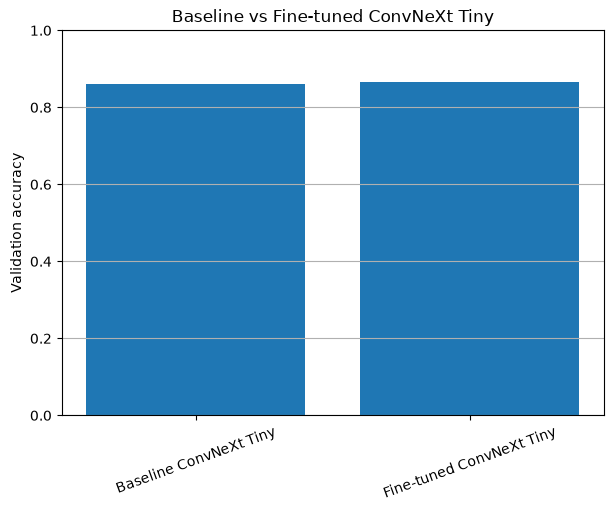

In [43]:
plt.figure(figsize=(7,5))

plt.bar(comparison_df['Model'], comparison_df['Validation accuracy'])
plt.ylabel('Validation accuracy')
plt.title('Baseline vs Fine-tuned ConvNeXt Tiny')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

### 16. Fine-tuning summary

In [44]:
print('=' * 60)
print('FINE-TUNING SUMMARY')
print('=' * 60)
print(f'Baseline validation accuracy : {baseline_accuracy:.4f}')
print(f'Final validation accuracy    : {final_accuracy:.4f}')
improvment = (best_phase2_acc - baseline_accuracy) * 100
print(f'Improvment                   : +{improvment:.2f}%')
print()
print(FINETUNED_MODEL_PATH)
print('=' * 60)

FINE-TUNING SUMMARY
Baseline validation accuracy : 0.8598
Final validation accuracy    : 0.8657
Improvment                   : +0.59%

../models/best_convnext_tiny_finetuned.pth
